In [5]:
import scipy.linalg as linal
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import scipy.optimize as optimize 
from scipy.stats.distributions import chi2

In [6]:
data1 = scipy.io.loadmat(r'ipca model/flowdata1.mat')
data2 = scipy.io.loadmat(r'ipca model/flowdata2.mat')
data3 = scipy.io.loadmat(r'ipca model/flowdata3.mat')

# Z1 = data1['Fmeas']
# Z2 = data2['Fmeas']
Z   = data3['Fmeas']
At  = data3['Atrue']
std = data3['std']

N = 1000 # Number of Samples
p = 5    # Number of Flow Parameters ( Variables )
m = 3    # Number of Constraints 

mean_shift = lambda x : x - x.mean(axis=0)

In [7]:
def maximum_likelihood (x, A, R) : 
    L       = np.matrix( [[ x[0],    0 ,   0 ,   0 ,   0  ],  \
                          [   0 ,  x[1],   0 ,   0 ,   0  ],  \
                          [   0 ,    0 , x[2],   0 ,   0  ],  \
                          [   0 ,    0 , x[3], x[4],   0  ],  \
                          [   0 ,    0 ,    0,   0 , x[5] ]]  )
    sigma_e = L@L.T
    sigma_r = A@sigma_e@A.T
    sum = 0 

    for i in range(1000) : 
        ri  = R[:,[i]]
        sum = sum + ri.T@linal.inv(sigma_r)@ri

    sum = sum + 1000*np.log(np.linalg.det(sigma_r))

    return sum

In [19]:
np.set_printoptions(suppress=True)

tolerance = 0.001
Zm        = mean_shift(Z)

L         = np.matrix([ [ 1, 0, 0, 0, 0 ], \
                        [ 0, 1, 0, 0, 0 ], \
                        [ 0, 0, 1, 0, 0 ], \
                        [ 0, 0, 0, 1, 0 ], \
                        [ 0, 0, 0, 0, 1 ] ])

plotting = np.empty((15,1))
std_p    = np.empty((6 ,1))

for i in range(10) : 
    print(i)
    # COMPUTE A
    scale   = np.linalg.inv(L.T)
    Zs      = Zm@scale/np.sqrt(N)
    u, s, v = np.linalg.svd(Zs)
    evals   = s**2
    As      = v [-m:,:]
    A       = As@(scale.T)

    # COMPUTE L
    # R       = Zm@scale@As.T
    R       = Zm@(A.T)
        
    t       = 1
    x0      = np.array([ t,t,t,t,t,t ])
    x       = optimize.minimize( maximum_likelihood, x0, args=(A, R.T), tol = tolerance)
    message = x['message']
    u       = x['x']

    print(message,'\n')

    L       = np.matrix([ [ u[0],   0 ,   0 ,   0 ,   0  ], \
                          [   0 , u[1],   0 ,   0 ,   0  ], \
                          [   0 ,   0 , u[2],   0 ,   0  ], \
                          [   0 ,   0 , u[3], u[4],   0  ], \
                          [   0 ,   0 ,   0 ,   0 , u[5] ]  ])
    
    print(np.round(L,4))
    print('-------------------------------------------','\n')

    plotting = np.append(plotting, A.flatten('C')[np.newaxis].T, axis=1)
    std_p    = np.append(std_p   , u[np.newaxis].T, axis=1)

plotting = plotting [:, 1:]
std_p    = std_p    [:, 1:]

0
Desired error not necessarily achieved due to precision loss. 

[[-0.1058  0.      0.      0.      0.    ]
 [ 0.     -0.0005  0.      0.      0.    ]
 [ 0.      0.      0.2024  0.      0.    ]
 [ 0.      0.      0.224  -0.0823  0.    ]
 [ 0.      0.      0.      0.     -0.1872]]
------------------------------------------- 

1
Optimization terminated successfully. 

[[-0.1058  0.      0.      0.      0.    ]
 [ 0.     -0.0003  0.      0.      0.    ]
 [ 0.      0.     -0.2008  0.      0.    ]
 [ 0.      0.     -0.222   0.0823  0.    ]
 [ 0.      0.      0.      0.     -0.1864]]
------------------------------------------- 

2
Desired error not necessarily achieved due to precision loss. 

[[-0.1058  0.      0.      0.      0.    ]
 [ 0.     -0.0001  0.      0.      0.    ]
 [ 0.      0.     -0.2008  0.      0.    ]
 [ 0.      0.     -0.222   0.0823  0.    ]
 [ 0.      0.      0.      0.     -0.1864]]
------------------------------------------- 

3
Desired error not necessarily achieved

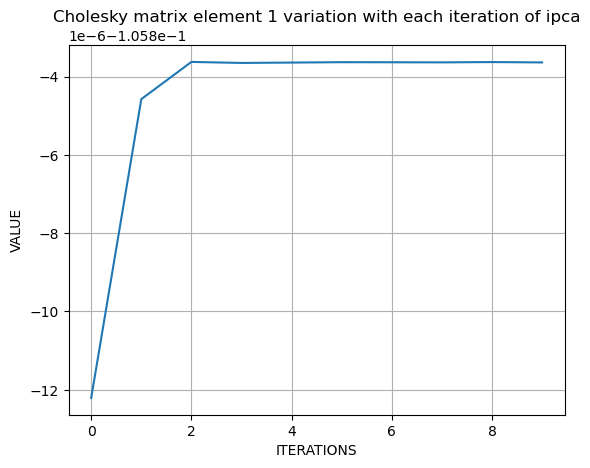

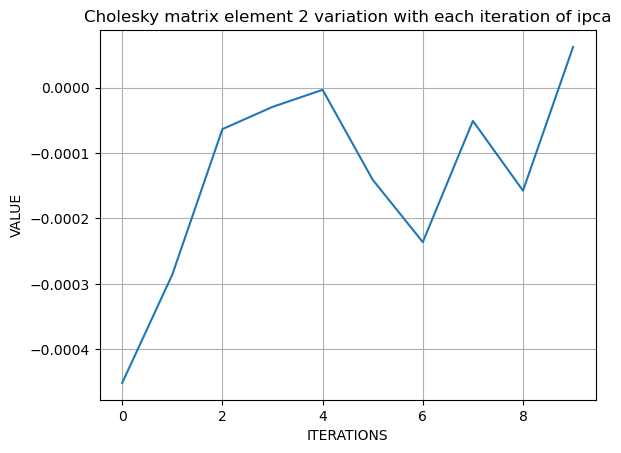

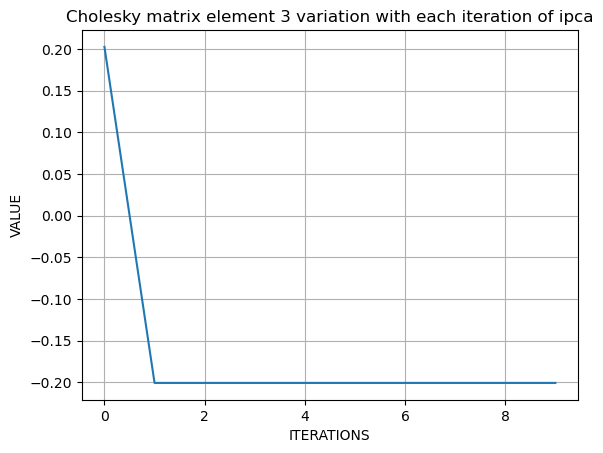

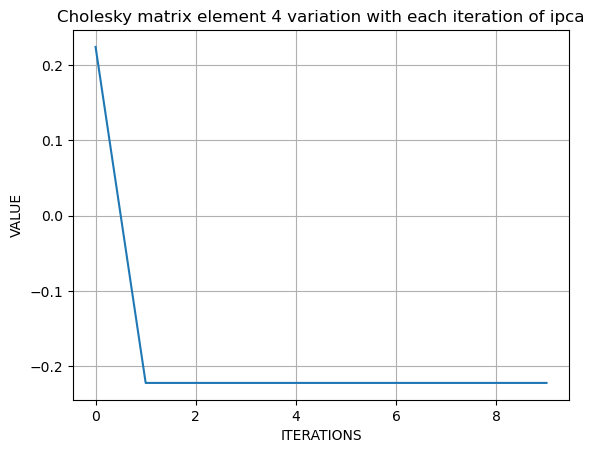

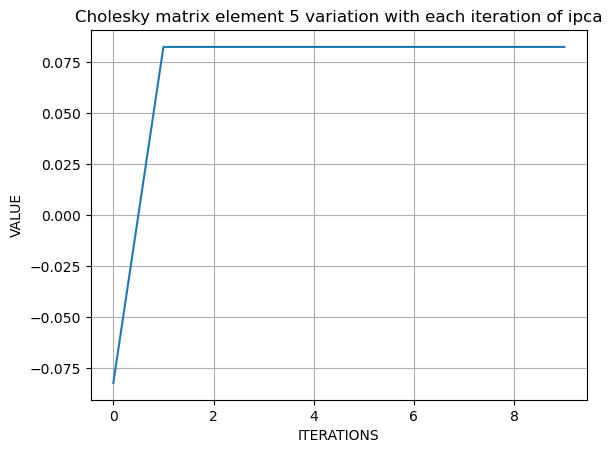

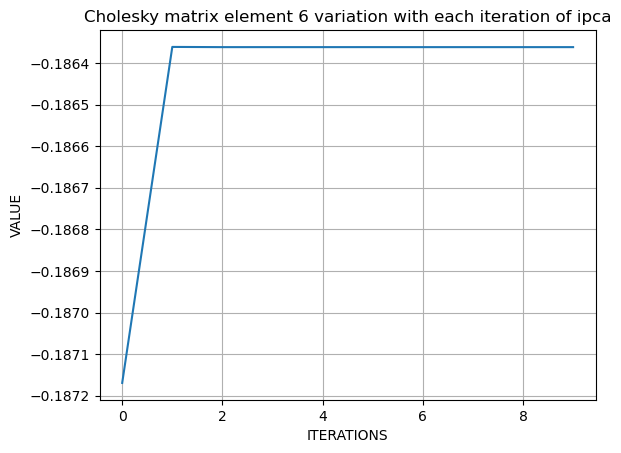

In [20]:
for i in range(6) : 
    plt.plot(std_p[i,:])
    # plt.grid()
    plt.title(f"Cholesky matrix element {i+1} variation with each iteration of ipca")
    plt.xlabel("ITERATIONS")
    plt.ylabel("VALUE")
    plt.grid()
    plt.show()

### <u> Cholesky Matrix </u>  :

In [21]:
L

matrix([[-0.10580364,  0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.00006253,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        , -0.20082279,  0.        ,  0.        ],
        [ 0.        ,  0.        , -0.22195259,  0.08228568,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        , -0.18636197]])

In [22]:
std

array([[0.1 , 0.08, 0.15, 0.2 , 0.18, 0.12]])

### <u> Converged Constraint Matrix </u> : 

In [23]:
# Converged constraint matrix 
np.round(A,4)

array([[-3.2977,  0.1231,  8.0981, -8.2361,  3.3002],
       [ 3.5059,  4.634 , -7.7829,  3.1362,  1.1292],
       [ 3.2977,  0.1814,  8.0981, -8.2361, -3.3002]])

In [24]:
At

array([[ 1,  1, -1,  0,  0],
       [ 0,  0,  1, -1,  0],
       [ 0, -1,  0,  1, -1]], dtype=int16)

### <u> Hypothesis Testing </u> : 

In [43]:
d = p-1
Y = Zm@np.linalg.inv(L.T)

evals = np.sort(np.linalg.eig( Y.T@Y / N) [0]).real [::-1]
while d > 1 : 
    n_dash = N - (2*p+11)/6
    l_dash = evals[ p-d : ].sum()/d 
    tau    = n_dash * ( d * np.log(l_dash) - np.log(evals[ p-d : ]).sum())
    fdom   = 0.5*(d+2)*(d-1)
    chi    = chi2.ppf(0.95, df=fdom)

    print(d,"| Test Statistic :", np.round(tau,3),'\t Chi2 Value :', np.round(chi,3))

    if (tau <= chi) : 
        print()
        print("Number of Constraints :", d)
        break 
    else : 
        d = d - 1 

4 | Test Statistic : 6085.81 	 Chi2 Value : 16.919
3 | Test Statistic : 0.824 	 Chi2 Value : 11.07

Number of Constraints : 3


* The Hypothesis test has correctly identified 3 constraints among the variables 
---
### <u> Converged Eigenvectors : 

In [26]:
# Converged EigenVectors 
As

matrix([[ 0.34890984, -0.00001938,  0.20174314, -0.67771667, -0.61502987],
        [-0.37093703, -0.00072955,  0.86690513,  0.25806348, -0.21043746],
        [-0.34890788, -0.00002857,  0.20174784, -0.67771501,  0.61503127]])

### <u> Regression Matrix </u> : 

In [27]:
true_regression = -np.linalg.inv(At[:,[2,3,4]])@At[:,[0,1]]
true_regression

array([[1., 1.],
       [1., 1.],
       [1., 0.]])

In [28]:
converged_regression = -np.linalg.inv(A[:,[2,3,4]])@A[:,[0,1]]
converged_regression

matrix([[0.98615172, 1.00055523],
        [0.96962429, 1.00227693],
        [0.99924115, 0.00883317]])

In [30]:
diff = np.abs(true_regression - converged_regression)

In [38]:
print("CHOLESKY MATRIX : ")
print(L)
print()
print("STANDARD DEVIATION VALUES FOR flowdatat3 :")
print(std)
print("----------------------------------------------------------------")
print("CONVERGED CONSTRAINT MATRIX : ")
print(A)
print()
print("CONVERGED EIGENVECTORS :")
print(As)
print("----------------------------------------------------------------")
print("TRUE REGRESSION MATRIX :")
print(true_regression)
print()
print("CONVERGED REGRESSION MATRIX :")
print(converged_regression)
print()
print("ABSOLUTE DIFFERENCE BETWEEN REGRESSION MATRICES :")
print(diff)

CHOLESKY MATRIX : 
[[-0.10580364  0.          0.          0.          0.        ]
 [ 0.          0.00006253  0.          0.          0.        ]
 [ 0.          0.         -0.20082279  0.          0.        ]
 [ 0.          0.         -0.22195259  0.08228568  0.        ]
 [ 0.          0.          0.          0.         -0.18636197]]

STANDARD DEVIATION VALUES FOR flowdatat3 :
[[0.1  0.08 0.15 0.2  0.18 0.12]]
----------------------------------------------------------------
CONVERGED CONSTRAINT MATRIX : 
[[-3.29771139  0.1231134   8.09813579 -8.23614353  3.30018996]
 [ 3.50590075  4.63395305 -7.78293632  3.13618942  1.12918676]
 [ 3.29769289  0.18144123  8.09809006 -8.23612332 -3.30019748]]

CONVERGED EIGENVECTORS :
[[ 0.34890984 -0.00001938  0.20174314 -0.67771667 -0.61502987]
 [-0.37093703 -0.00072955  0.86690513  0.25806348 -0.21043746]
 [-0.34890788 -0.00002857  0.20174784 -0.67771501  0.61503127]]
----------------------------------------------------------------
TRUE REGRESSION MATR